In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import pandas as pd
import pandas as pd
import numpy as np
import re
from hazm import *

normalizer = Normalizer(
    correct_spacing=True,
    remove_diacritics=True,
    remove_specials_chars=True,
    decrease_repeated_chars=True,
    persian_style=True,
    persian_numbers=True,
    unicodes_replacement=True,
    seperate_mi=True
)
tokenizer = WordTokenizer()
lemmatizer = Lemmatizer()
df=pd.read_csv('../data/cleaned_dataset.csv')
unclean_data=pd.read_csv("../data/farsi_dari_toxic_comments.csv")


### class imbalance

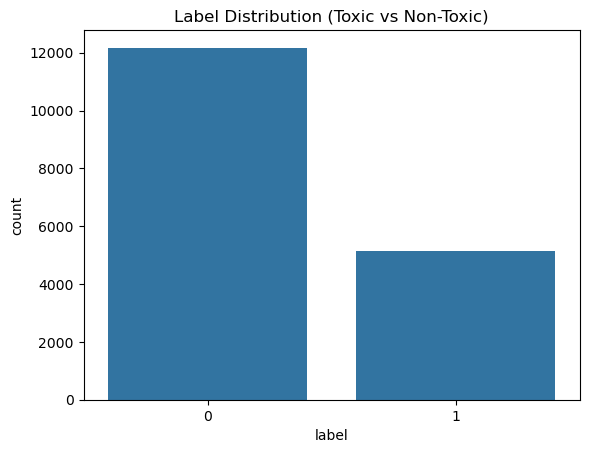

In [2]:
sns.countplot(data=df, x="label")
plt.title("Label Distribution (Toxic vs Non-Toxic)")
plt.show()

In [3]:
unclean_data["length"] = unclean_data["comment"].astype(str).apply(len)

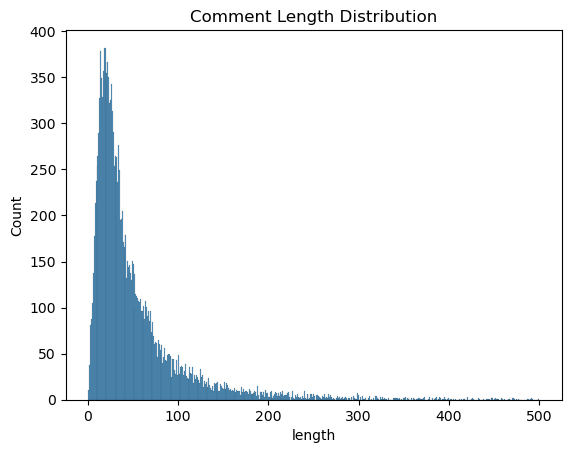

In [4]:
df["length"] = df["comment"].astype(str).apply(len)

sns.histplot(df["length"], bins=500)
plt.title("Comment Length Distribution")
plt.show()

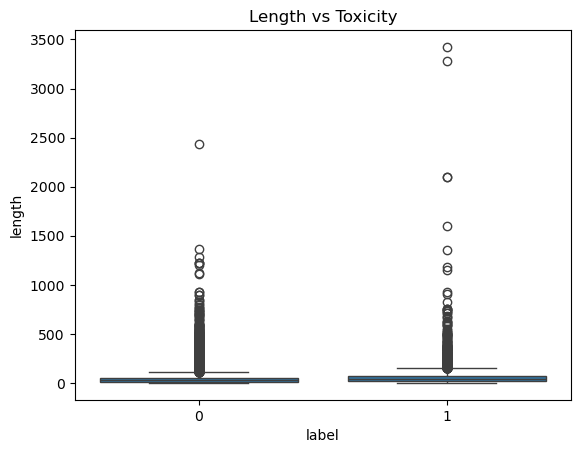

In [5]:

sns.boxplot(data=unclean_data, x="label", y="length")
plt.title("Length vs Toxicity")
plt.show()

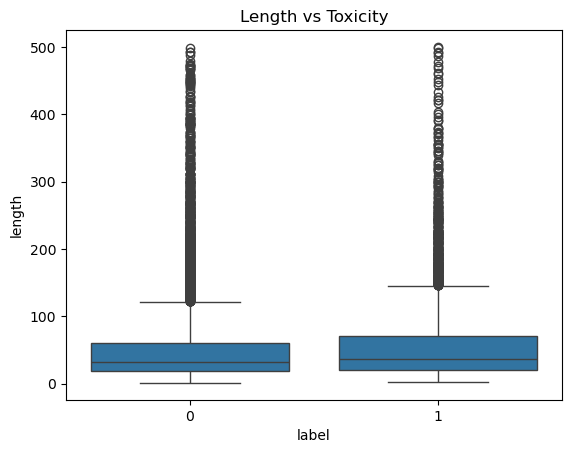

In [6]:
sns.boxplot(data=df, x="label", y="length")
plt.title("Length vs Toxicity")
plt.show()

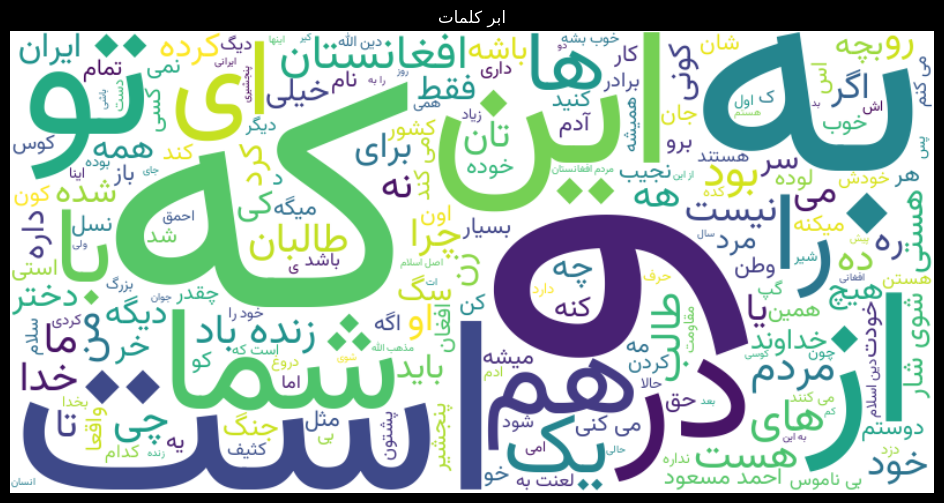

In [18]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt

# Combine all comments
text = " ".join(df["comment"].astype(str))

# Fix Persian text
reshaped_text = arabic_reshaper.reshape(text)
bidi_text = get_display(reshaped_text)

# Use a Persian-supporting font
font_path = "Vazirmatn/static/Vazirmatn-Regular.ttf"

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    font_path=font_path
).generate(bidi_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.title(
    get_display(arabic_reshaper.reshape("ابر کلمات"))
)

plt.show()

In [8]:
def clean_text_fa(text):
    text = str(text)
    text = normalizer.normalize(text)  # normalize Persian text
    
    # remove punctuation & numbers
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    
    words = word_tokenize(text)
    
    return words

In [9]:
from collections import Counter
toxic_df = df[df['label'] == 1]
non_toxic_df = df[df['label'] == 0]

toxic_words = toxic_df['comment'].apply(clean_text_fa)
non_toxic_words = non_toxic_df['comment'].apply(clean_text_fa)

all_toxic = [w for words in toxic_words for w in words]
all_non_toxic = [w for words in non_toxic_words for w in words]

toxic_counter = Counter(all_toxic)
non_toxic_counter = Counter(all_non_toxic)

toxic_score = {}

for word in toxic_counter:
    toxic_score[word] = toxic_counter[word] / (non_toxic_counter.get(word, 1))

top_keywords = sorted(toxic_score.items(), key=lambda x: x[1], reverse=True)[:100]

print(top_keywords)

[('کوسی', 123.0), ('کیرم', 107.5), ('گایم', 101.0), ('کوس', 88.6), ('جنده', 65.0), ('کص', 60.0), ('فایشه', 33.0), ('گوخوردی', 30.0), ('کسکش', 28.0), ('بگایم', 28.0), ('خوردی', 27.166666666666668), ('نالت', 25.0), ('گایدم', 24.0), ('گاییدم', 24.0), ('کونی', 21.083333333333332), ('شپشی', 20.0), ('ریدم', 19.5), ('بیعقل', 19.25), ('حرامزاده', 19.0), ('خایه', 18.0), ('بگایه', 17.0), ('کونش', 16.0), ('فاحشه', 16.0), ('توف', 15.0), ('حرومزاده', 15.0), ('کونت', 13.333333333333334), ('بخور', 13.0), ('کونیها', 12.0), ('خاندان', 12.0), ('کایم', 12.0), ('گوزوک', 12.0), ('گاید', 12.0), ('کوص', 12.0), ('حروم', 12.0), ('گوساله', 12.0), ('بیشرف', 11.8), ('کیر', 11.8), ('گوه', 11.076923076923077), ('ریدن', 11.0), ('گایده', 11.0), ('کشاد', 11.0), ('خوردین', 11.0), ('کون', 10.588235294117647), ('بیناموس', 10.578947368421053), ('تخم', 10.5), ('کصکش', 10.0), ('خاندانته', 10.0), ('بیدین', 10.0), ('حرامیها', 10.0), ('خوار', 9.714285714285714), ('خوارته', 9.0), ('خرکوس', 9.0), ('پدری', 9.0), ('موردگو', 9.0), 

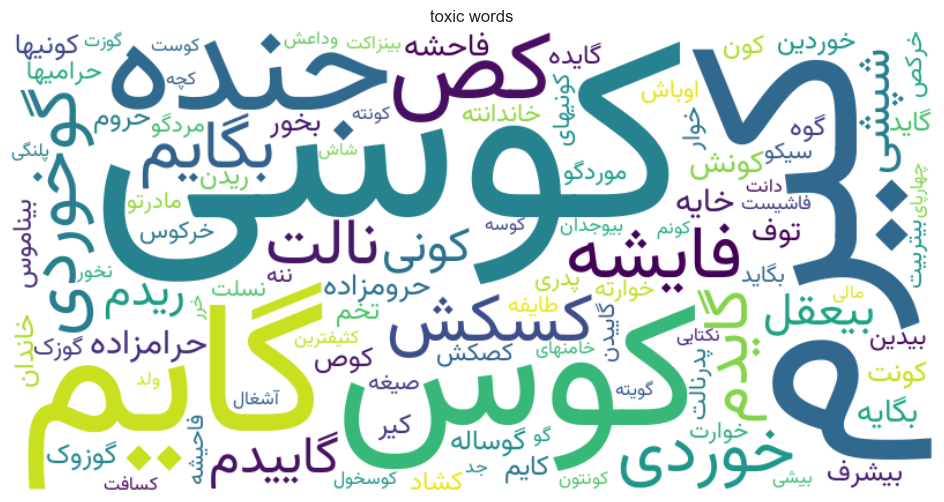

In [19]:
import arabic_reshaper
from bidi.algorithm import get_display

freq_dict = {
    get_display(arabic_reshaper.reshape(word)): score
    for word, score in top_keywords
}

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    font_path=font_path
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("toxic words")
plt.show()